In [17]:
!pip install transformers torch torchvision opencv-python matplotlib requests pillow

In [18]:
import torch
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from torchvision.utils import draw_segmentation_masks
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import os


In [19]:
model_name = "facebook/deit-base-distilled-patch16-224"  # For feature extraction
# Better option - using a proper segmentation model:
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"  # Valid segmentation model

In [20]:
try:
    processor = AutoImageProcessor.from_pretrained(model_name)
    model = AutoModelForSemanticSegmentation.from_pretrained(model_name)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Trying alternative model...")
    model_name = "mattmdjaga/seem"  # Another valid segmentation model
    try:
        processor = AutoImageProcessor.from_pretrained(model_name)
        model = AutoModelForSemanticSegmentation.from_pretrained(model_name)
        print("Alternative model loaded successfully!")
    except Exception as e:
        print(f"Failed to load all models: {e}")
        raise

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Model loaded successfully!


In [21]:
def segment_image(image_path):
    try:
        # Load image
        if image_path.startswith(('http://', 'https://')):
            response = requests.get(image_path)
            response.raise_for_status()
            image = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            if not os.path.exists(image_path):
                raise FileNotFoundError(f"Image not found at {image_path}")
            image = Image.open(image_path).convert("RGB")

        # Preprocess image
        inputs = processor(images=image, return_tensors="pt")

        # Get predictions
        with torch.no_grad():
            outputs = model(**inputs)

        # Process outputs
        logits = outputs.logits
        upsampled_logits = torch.nn.functional.interpolate(
            logits,
            size=image.size[::-1],
            mode="bilinear",
            align_corners=False
        )
        pred_mask = torch.argmax(upsampled_logits.squeeze(), dim=0).detach().cpu().numpy()

        return image, pred_mask
    except Exception as e:
        print(f"Error during segmentation: {e}")
        return None, None

In [22]:
def display_results(image, pred_mask, class_names):
    if image is None or pred_mask is None:
        print("No valid image or mask to display")
        return

    # Create color mask
    mask = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.uint8)
    for i in range(len(class_names)):
        mask[pred_mask == i] = np.random.randint(0, 255, (1, 3))

    # Display
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(image)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(mask)
    ax[1].set_title("Segmentation Mask")
    ax[1].axis('off')

    ax[2].imshow(draw_segmentation_masks(image, masks=pred_mask[None], alpha=0.7))
    ax[2].set_title("Overlay")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()


Processing image 1: https://images.unsplash.com/photo-1506748686214-e9df14d4d9d0


TypeError: The image must be a tensor, got <class 'PIL.Image.Image'>

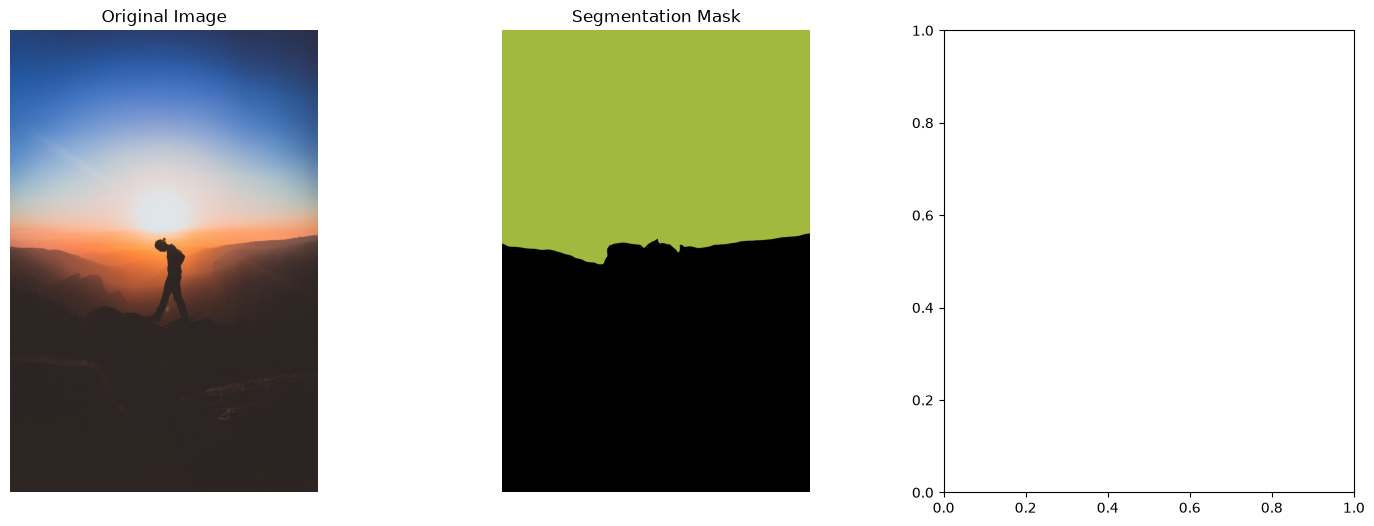

In [23]:
sample_images = [
    "https://images.unsplash.com/photo-1506748686214-e9df14d4d9d0",  # Street scene
    "https://images.unsplash.com/photo-1507146426996-ef05306b995a",  # Indoor scene
    "https://images.unsplash.com/photo-1516116216624-53e09716f316"   # Nature scene
]

# Get class names (simplified for demo)
class_names = [f"class_{i}" for i in range(10)]  # Replace with actual class names from your model

for i, img_url in enumerate(sample_images):
    print(f"\nProcessing image {i+1}: {img_url}")
    image, pred_mask = segment_image(img_url)
    if image is not None:
        display_results(image, pred_mask, class_names)